<a href="https://colab.research.google.com/github/guthasushmasree/ML-LabPrograms/blob/main/ml(skill_14).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Upload placement_predict_50k Dataset.csv


Saving placement_predict_50k Dataset.csv to placement_predict_50k Dataset.csv

Dataset loaded successfully!
Shape: (50000, 32)

Columns:
['StudentID', 'Gender', 'City', 'CollegeTier', 'Stream', 'Specialisation', 'Hostel', 'HistoryOfBacklogs', 'SGPA_Sem1', 'SGPA_Sem2', 'SGPA_Sem3', 'SGPA_Sem4', 'SGPA_Sem5', 'SGPA_Sem6', 'SGPA_Sem7', 'SGPA_Sem8', 'CGPA', 'AttendancePercent', 'Internships', 'Projects', 'Workshops', 'Certifications', 'Publications', 'AptitudeTestScore', 'SoftSkillsRating', 'CodingTestScore', 'MockInterviewScore', 'ExtraCurricular', 'CGPA_Tier', 'PlacementStatus', 'IsAnomaly', 'Salary Package']

All required columns found!

Converting feature columns...

Missing values before cleaning:
CGPA                     0
AttendancePercent        0
SGPA_Sem1                0
SGPA_Sem2                0
SGPA_Sem3                0
SGPA_Sem4                0
SGPA_Sem5                0
SGPA_Sem6                0
SGPA_Sem7                0
SGPA_Sem8                0
Internships            

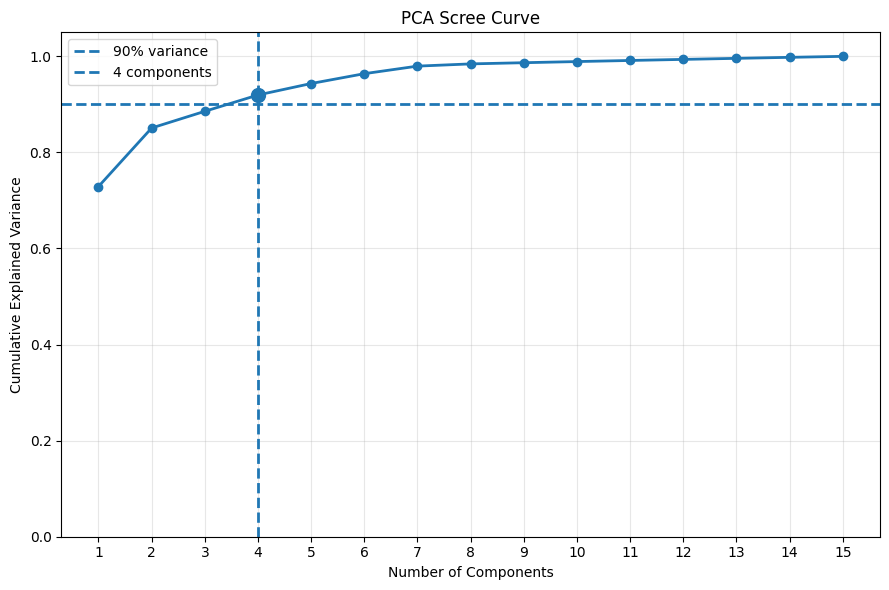


Components needed for 90% variance: 4


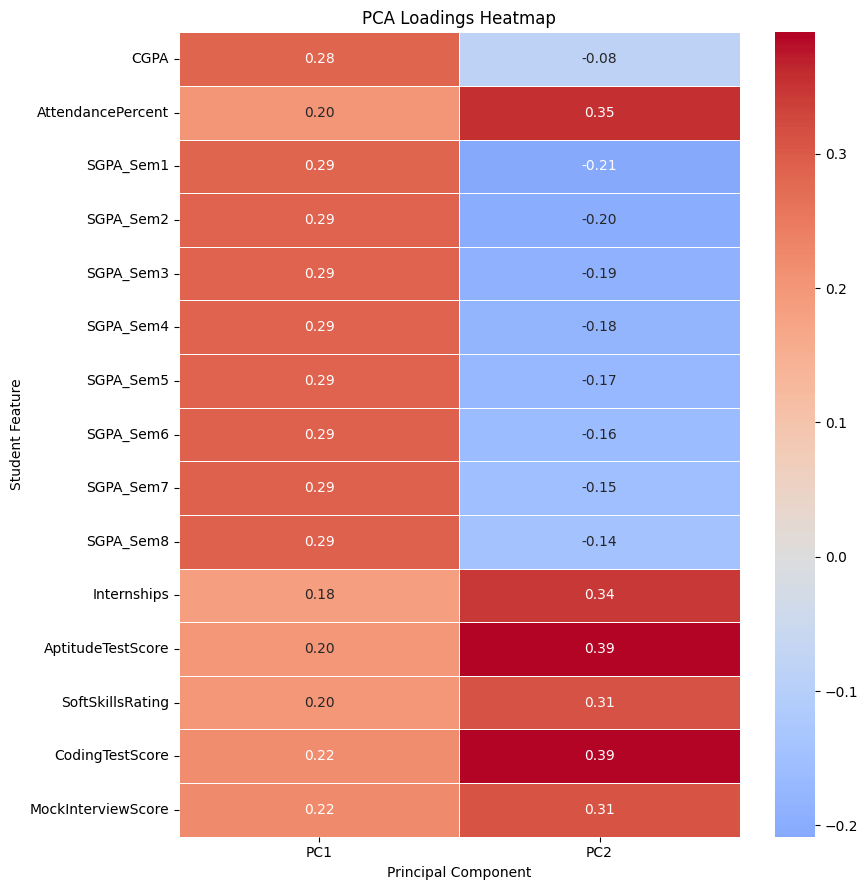


PCA LOADINGS:


,PC1,PC2
CGPA,0.283747,-0.082621
AttendancePercent,0.202070,0.353337
SGPA_Sem1,0.285010,-0.208376
SGPA_Sem2,0.286403,-0.197872
SGPA_Sem3,0.287454,-0.189615
SGPA_Sem4,0.288474,-0.180582
SGPA_Sem5,0.289468,-0.171236
SGPA_Sem6,0.290339,-0.162537
SGPA_Sem7,0.291215,-0.153451
SGPA_Sem8,0.291940,-0.144502



PC1 represents an overall student ability/performance dimension.

PC1 feature contributions:
CGPA                      +0.284
AttendancePercent         +0.202
SGPA_Sem1                 +0.285
SGPA_Sem2                 +0.286
SGPA_Sem3                 +0.287
SGPA_Sem4                 +0.288
SGPA_Sem5                 +0.289
SGPA_Sem6                 +0.290
SGPA_Sem7                 +0.291
SGPA_Sem8                 +0.292
Internships               +0.184
AptitudeTestScore         +0.200
SoftSkillsRating          +0.201
CodingTestScore           +0.218
MockInterviewScore        +0.223

Running PCA 2D...
PCA time: 0.02 seconds

Running t-SNE...


In [ ]:
# ============================================================
# PLACEMENT DATASET
# PCA + t-SNE + UMAP
# GOOGLE COLAB - CORRECTED VERSION
# ============================================================

!pip -q install umap-learn


# ============================================================
# IMPORT LIBRARIES
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import time

from google.colab import files

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

import umap


# ============================================================
# UPLOAD DATASET
# ============================================================

print("Upload placement_predict_50k Dataset.csv")

uploaded = files.upload()

filename = list(uploaded.keys())[0]

df = pd.read_csv(filename)

print("\nDataset loaded successfully!")
print("Shape:", df.shape)

print("\nColumns:")
print(df.columns.tolist())


# ============================================================
# SELECT NUMERIC FEATURES
# ============================================================
#
# We use columns that represent student performance.
#
# IMPORTANT:
# We are NOT using HistoryOfBacklogs, Projects,
# Workshops, Certifications, Publications or
# ExtraCurricular because these may contain categorical
# values in your dataset.
# ============================================================

features = [
    "CGPA",
    "AttendancePercent",
    "SGPA_Sem1",
    "SGPA_Sem2",
    "SGPA_Sem3",
    "SGPA_Sem4",
    "SGPA_Sem5",
    "SGPA_Sem6",
    "SGPA_Sem7",
    "SGPA_Sem8",
    "Internships",
    "AptitudeTestScore",
    "SoftSkillsRating",
    "CodingTestScore",
    "MockInterviewScore"
]

target = "PlacementStatus"


# ============================================================
# CHECK COLUMNS
# ============================================================

missing = [
    col for col in features + [target]
    if col not in df.columns
]

if len(missing) > 0:

    print("\nMissing columns:")
    print(missing)

    raise ValueError(
        "Some required columns are missing."
    )


print("\nAll required columns found!")


# ============================================================
# CREATE COPY
# ============================================================

data = df[features + [target]].copy()


# ============================================================
# CONVERT FEATURES TO NUMERIC
# ============================================================

print("\nConverting feature columns...")


for column in features:

    data[column] = pd.to_numeric(
        data[column],
        errors="coerce"
    )


# ============================================================
# CHECK MISSING VALUES BEFORE CLEANING
# ============================================================

print("\nMissing values before cleaning:")

print(
    data[features].isna().sum()
)


# ============================================================
# FILL NUMERIC MISSING VALUES
# ============================================================
#
# Instead of dropna(), use median.
# This prevents all rows from being deleted.
# ============================================================

for column in features:

    median_value = data[column].median()

    data[column] = data[column].fillna(
        median_value
    )


# ============================================================
# CONVERT PLACEMENT STATUS
# ============================================================

print("\nPlacementStatus values:")

print(
    data[target].unique()
)


# Convert target to numeric
if data[target].dtype == "object":

    status = (
        data[target]
        .astype(str)
        .str.strip()
        .str.lower()
    )

    # Try common labels
    mapping = {
        "placed": 1,
        "not placed": 0,
        "not_placed": 0,
        "notplaced": 0,
        "yes": 1,
        "no": 0,
        "true": 1,
        "false": 0,
        "1": 1,
        "0": 0
    }

    converted = status.map(mapping)

    # If mapping worked
    if converted.notna().all():

        data[target] = converted.astype(int)

    else:

        # Automatically encode remaining categories
        data[target] = pd.factorize(
            status
        )[0]

else:

    data[target] = pd.to_numeric(
        data[target],
        errors="coerce"
    )

    data[target] = data[target].fillna(0)


# ============================================================
# CHECK DATA
# ============================================================

print("\nRows available for analysis:")

print(
    len(data)
)


print("\nFinal missing values:")

print(
    data[features].isna().sum().sum()
)


# ============================================================
# CREATE X AND Y
# ============================================================

X_raw = data[features]

y = data[target].values


# ============================================================
# STANDARDIZE
# ============================================================

scaler = StandardScaler()

X = scaler.fit_transform(
    X_raw
)

print(
    "\nData standardized successfully!"
)


# ============================================================
# PCA
# ============================================================

print("\nRunning PCA...")

pca_full = PCA()

pca_full.fit(X)


explained_variance = (
    pca_full.explained_variance_ratio_
)


cumulative_variance = np.cumsum(
    explained_variance
)


# ============================================================
# FIND 90% VARIANCE
# ============================================================

components_90 = (
    np.argmax(
        cumulative_variance >= 0.90
    ) + 1
)


# ============================================================
# SCREE CURVE
# ============================================================

plt.figure(
    figsize=(9, 6)
)

plt.plot(
    range(
        1,
        len(cumulative_variance) + 1
    ),
    cumulative_variance,
    marker="o",
    linewidth=2
)


plt.axhline(
    0.90,
    linestyle="--",
    linewidth=2,
    label="90% variance"
)


plt.axvline(
    components_90,
    linestyle="--",
    linewidth=2,
    label=f"{components_90} components"
)


plt.scatter(
    components_90,
    cumulative_variance[
        components_90 - 1
    ],
    s=100,
    zorder=5
)


plt.xlabel(
    "Number of Components"
)

plt.ylabel(
    "Cumulative Explained Variance"
)

plt.title(
    "PCA Scree Curve"
)


plt.xticks(
    range(
        1,
        len(features) + 1
    )
)


plt.ylim(
    0,
    1.05
)


plt.grid(
    alpha=0.3
)


plt.legend()

plt.tight_layout()

plt.show()


print(
    "\nComponents needed for 90% variance:",
    components_90
)


# ============================================================
# PCA LOADINGS
# ============================================================

pca_2 = PCA(
    n_components=2
)

pca_2.fit(X)


loadings = pd.DataFrame(
    pca_2.components_.T,
    index=features,
    columns=[
        "PC1",
        "PC2"
    ]
)


# ============================================================
# LOADINGS HEATMAP
# ============================================================

plt.figure(
    figsize=(9, 9)
)


sns.heatmap(
    loadings,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    linewidths=0.5
)


plt.title(
    "PCA Loadings Heatmap"
)


plt.xlabel(
    "Principal Component"
)


plt.ylabel(
    "Student Feature"
)


plt.tight_layout()

plt.show()


# ============================================================
# PRINT LOADINGS
# ============================================================

print("\nPCA LOADINGS:")

display(
    loadings
)


# ============================================================
# PC1 INTERPRETATION
# ============================================================

print(
    "\nPC1 represents an overall student "
    "ability/performance dimension."
)


print(
    "\nPC1 feature contributions:"
)


for feature in features:

    print(
        f"{feature:25s} "
        f"{loadings.loc[feature, 'PC1']:+.3f}"
    )


# ============================================================
# PCA 2D
# ============================================================

print(
    "\nRunning PCA 2D..."
)


start = time.time()


pca_embedding = PCA(
    n_components=2
).fit_transform(X)


pca_time = (
    time.time() - start
)


print(
    f"PCA time: {pca_time:.2f} seconds"
)


# ============================================================
# t-SNE
# ============================================================

print(
    "\nRunning t-SNE..."
)


start = time.time()


tsne_embedding = TSNE(
    n_components=2,
    perplexity=30,
    init="pca",
    random_state=42,
    learning_rate="auto"
).fit_transform(X)


tsne_time = (
    time.time() - start
)


print(
    f"t-SNE time: {tsne_time:.2f} seconds"
)


# ============================================================
# UMAP
# ============================================================

print(
    "\nRunning UMAP..."
)


start = time.time()


umap_embedding = umap.UMAP(
    n_components=2,
    n_neighbors=15,
    min_dist=0.1,
    random_state=42
).fit_transform(X)


umap_time = (
    time.time() - start
)


print(
    f"UMAP time: {umap_time:.2f} seconds"
)


# ============================================================
# TIMINGS
# ============================================================

print(
    "\n===================================="
)

print(
    "EMBEDDING EXECUTION TIMES"
)

print(
    "===================================="
)


print(
    f"PCA   : {pca_time:.2f} seconds"
)

print(
    f"t-SNE : {tsne_time:.2f} seconds"
)

print(
    f"UMAP  : {umap_time:.2f} seconds"
)


# ============================================================
# PCA vs t-SNE vs UMAP
# ============================================================

fig, axes = plt.subplots(
    1,
    3,
    figsize=(18, 5)
)


embeddings = [
    (
        "PCA",
        pca_embedding,
        pca_time
    ),
    (
        "t-SNE",
        tsne_embedding,
        tsne_time
    ),
    (
        "UMAP",
        umap_embedding,
        umap_time
    )
]


for ax, (
    name,
    embedding,
    timing
) in zip(
    axes,
    embeddings
):

    ax.scatter(
        embedding[:, 0],
        embedding[:, 1],
        c=y,
        cmap="coolwarm",
        s=12,
        alpha=0.7
    )


    ax.set_title(
        f"{name}\n"
        f"Time = {timing:.2f}s"
    )


    ax.set_xlabel(
        "Dimension 1"
    )


    ax.set_ylabel(
        "Dimension 2"
    )


plt.suptitle(
    "PCA vs t-SNE vs UMAP",
    fontsize=16
)


plt.tight_layout()

plt.show()


# ============================================================
# t-SNE PERPLEXITY COMPARISON
# ============================================================

print(
    "\nRunning t-SNE with "
    "different perplexities..."
)


perplexities = [
    5,
    30,
    50
]


fig, axes = plt.subplots(
    1,
    3,
    figsize=(18, 5)
)


for ax, perplexity in zip(
    axes,
    perplexities
):

    print(
        f"Perplexity = {perplexity}"
    )


    start = time.time()


    result = TSNE(
        n_components=2,
        perplexity=perplexity,
        init="pca",
        random_state=42,
        learning_rate="auto"
    ).fit_transform(X)


    elapsed = (
        time.time() - start
    )


    ax.scatter(
        result[:, 0],
        result[:, 1],
        c=y,
        cmap="coolwarm",
        s=10,
        alpha=0.7
    )


    ax.set_title(
        f"t-SNE\n"
        f"Perplexity = {perplexity}\n"
        f"Time = {elapsed:.2f}s"
    )


    ax.set_xlabel(
        "Dimension 1"
    )


    ax.set_ylabel(
        "Dimension 2"
    )


plt.suptitle(
    "t-SNE with Different Perplexities",
    fontsize=16
)


plt.tight_layout()

plt.show()


# ============================================================
# FINAL SUMMARY
# ============================================================

print("\n")
print(
    "=" * 60
)

print(
    "FINAL RESULTS"
)

print(
    "=" * 60
)


print(
    f"\nDataset rows analysed: "
    f"{len(data)}"
)


print(
    f"\nComponents needed for 90% variance: "
    f"{components_90}"
)


print(
    "\nEmbedding timings:"
)


print(
    f"PCA   : {pca_time:.2f}s"
)


print(
    f"t-SNE : {tsne_time:.2f}s"
)


print(
    f"UMAP  : {umap_time:.2f}s"
)


print(
    "\nt-SNE perplexities tested:"
)


print(
    "5, 30, 50"
)


print(
    "\n===================================="
)

print(
    "ANALYSIS COMPLETED SUCCESSFULLY!"
)

print(
    "===================================="
)